**Stacking (Meta)_Jaundice Detection – Stacking (Meta-Learner) V2 (NJN)**

In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm

In [2]:
import os, glob, random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, skew, kurtosis

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

from google.colab import drive

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Dataset Path
DATASET_PATH = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(DATASET_PATH, "**", ext), recursive=True)

print("Total images found:", len(all_imgs))
print("Sample paths:", all_imgs[:5])

Total images found: 760
Sample paths: ['/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1024).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (566).jpg']


Labeling

In [6]:
def infer_label_from_path(p):
    lp = p.lower()

    pos_keys = ["jaundice", "icteric", "positive", "pos", "case", "patient", "affected", "yellow"]
    neg_keys = ["normal", "control", "negative", "neg", "healthy", "non"]

    if any(k in lp for k in pos_keys):
        return 1
    if any(k in lp for k in neg_keys):
        return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p, l) for p, l in pairs if l is not None]

imgs = [p for p, l in pairs]
y_all = np.array([l for p, l in pairs])

print("Total labeled:", len(pairs))
print("Class counts (0=Normal, 1=Jaundice):", np.bincount(y_all))
print("Example:", pairs[:3])

Total labeled: 760
Class counts (0=Normal, 1=Jaundice): [560 200]
Example: [('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', 0)]


ROI Functions

In [7]:
# ----------------------------
# Improved Forehead ROI
# ----------------------------
def get_forehead_box(img_bgr):
    h, w = img_bgr.shape[:2]

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    candidates = []
    min_area = max(300, int(0.002 * h * w))
    for i in range(1, num_labels):
        x, y, bw, bh, area = stats[i]
        if area >= min_area:
            candidates.append((i, x, y, bw, bh, area))

    if candidates:
        candidates = sorted(candidates, key=lambda t: (t[2], -t[5]))
        _, x, y, bw, bh, area = candidates[0]

        pad_x = int(0.05 * bw)
        pad_y = int(0.05 * bh)
        x = max(0, x - pad_x)
        y = max(0, y - pad_y)
        bw = min(w - x, bw + 2 * pad_x)
        bh = min(h - y, bh + 2 * pad_y)

        x1 = max(0, x + int(0.18 * bw))
        x2 = min(w, x + int(0.68 * bw))
        y1 = max(0, y + int(0.08 * bh))
        y2 = min(h, y + int(0.22 * bh))
    else:
        x1 = int(0.28 * w)
        x2 = int(0.58 * w)
        y1 = int(0.10 * h)
        y2 = int(0.22 * h)

    if (x2 - x1) < 12 or (y2 - y1) < 12:
        x1 = int(0.28 * w)
        x2 = int(0.58 * w)
        y1 = int(0.10 * h)
        y2 = int(0.22 * h)

    return x1, y1, x2, y2, mask


def extract_forehead_roi(img_bgr):
    x1, y1, x2, y2, _ = get_forehead_box(img_bgr)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


# ----------------------------
# Chest ROI
# ----------------------------
def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.40 * h)
    y2 = int(0.80 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


# ----------------------------
# Abdomen ROI
# ----------------------------
def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.60 * h)
    y2 = int(0.92 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

ROI Preview

In [27]:
def get_forehead_box(img_bgr):
    h, w = img_bgr.shape[:2]

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    candidates = []
    min_area = max(300, int(0.002 * h * w))
    for i in range(1, num_labels):
        x, y, bw, bh, area = stats[i]
        if area >= min_area:
            candidates.append((i, x, y, bw, bh, area))

    if candidates:
        candidates = sorted(candidates, key=lambda t: (t[2], -t[5]))
        _, x, y, bw, bh, area = candidates[0]

        pad_x = int(0.05 * bw)
        pad_y = int(0.05 * bh)
        x = max(0, x - pad_x)
        y = max(0, y - pad_y)
        bw = min(w - x, bw + 2 * pad_x)
        bh = min(h - y, bh + 2 * pad_y)

        # Forehead -> slightly right + slightly bigger
        x1 = max(0, x + int(0.28 * bw))
        x2 = min(w, x + int(0.68 * bw))
        y1 = max(0, y + int(0.05 * bh))
        y2 = min(h, y + int(0.15 * bh))
    else:
        x1 = int(0.34 * w)
        x2 = int(0.60 * w)
        y1 = int(0.08 * h)
        y2 = int(0.15 * h)

    if (x2 - x1) < 12 or (y2 - y1) < 12:
        x1 = int(0.34 * w)
        x2 = int(0.60 * w)
        y1 = int(0.08 * h)
        y2 = int(0.15 * h)

    return x1, y1, x2, y2, mask


def extract_forehead_roi(img_bgr):
    x1, y1, x2, y2, _ = get_forehead_box(img_bgr)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

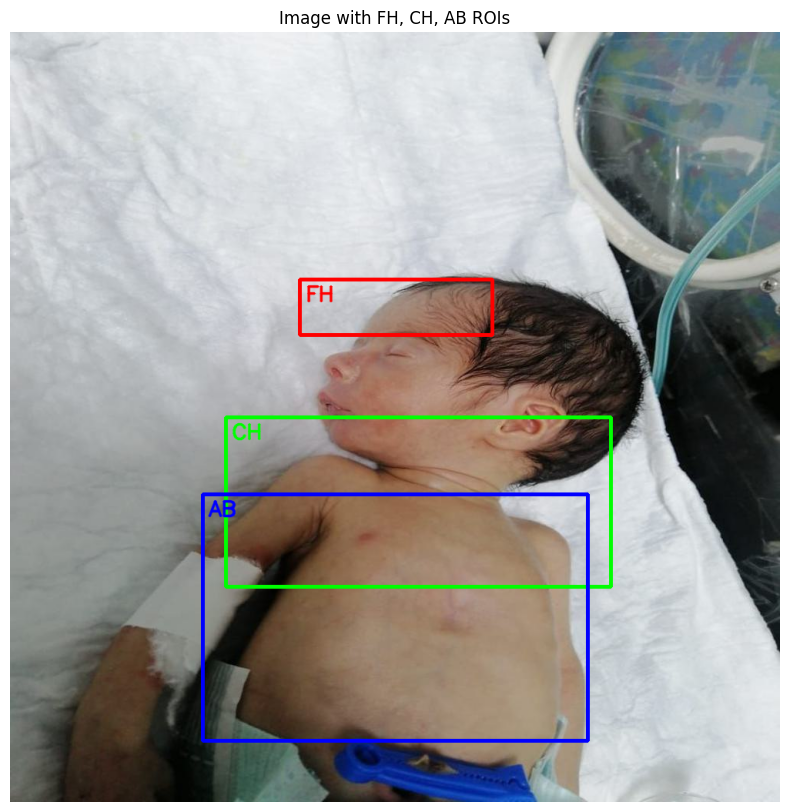

In [28]:
sample_path = imgs[0]
img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

vis = img_rgb.copy()

# FH
x1f, y1f, x2f, y2f, _ = get_forehead_box(img)
cv2.rectangle(vis, (x1f, y1f), (x2f, y2f), (255, 0, 0), 3)
cv2.putText(vis, "FH", (x1f + 8, y1f + 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2, cv2.LINE_AA)

# CH
h, w = img.shape[:2]
x1c, x2c = int(0.28 * w), int(0.78 * w)
y1c, y2c = int(0.50 * h), int(0.72 * h)
cv2.rectangle(vis, (x1c, y1c), (x2c, y2c), (0, 255, 0), 3)
cv2.putText(vis, "CH", (x1c + 8, y1c + 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2, cv2.LINE_AA)

# AB
x1a, x2a = int(0.25 * w), int(0.75 * w)
y1a, y2a = int(0.60 * h), int(0.92 * h)
cv2.rectangle(vis, (x1a, y1a), (x2a, y2a), (0, 0, 255), 3)
cv2.putText(vis, "AB", (x1a + 8, y1a + 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2, cv2.LINE_AA)

plt.figure(figsize=(10, 10))
plt.imshow(vis)
plt.title("Image with FH, CH, AB ROIs")
plt.axis("off")
plt.show()

Preprocess + Skin Mask + Feature Extraction

In [29]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)

    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0

    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))

    out = cv2.merge([b, g, r])
    return np.clip(out, 0, 255).astype(np.uint8)


def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    L2 = clahe.apply(L)

    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)


def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr


def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)

    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)

    return mask


def masked_stats(channel, mask):
    vals = channel[mask == 255].astype(np.float32)

    if vals.size < 30:
        return (np.nan,) * 6

    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )


def extract_features_from_roi(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)

    if np.sum(mask == 255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8) * 255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:, :, 0]
    G = roi_rgb[:, :, 1]
    B = roi_rgb[:, :, 2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))
    rg_balance = float((Rm - Gm) / (Rm + Gm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom)
    g_ch = float(Gm / denom)
    b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask == 255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0, 180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:, :, 0]
    a = lab[:, :, 1]
    b = lab[:, :, 2]

    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask == 255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "RG_balance": rg_balance,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }

    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

ROI Preprocess Preview

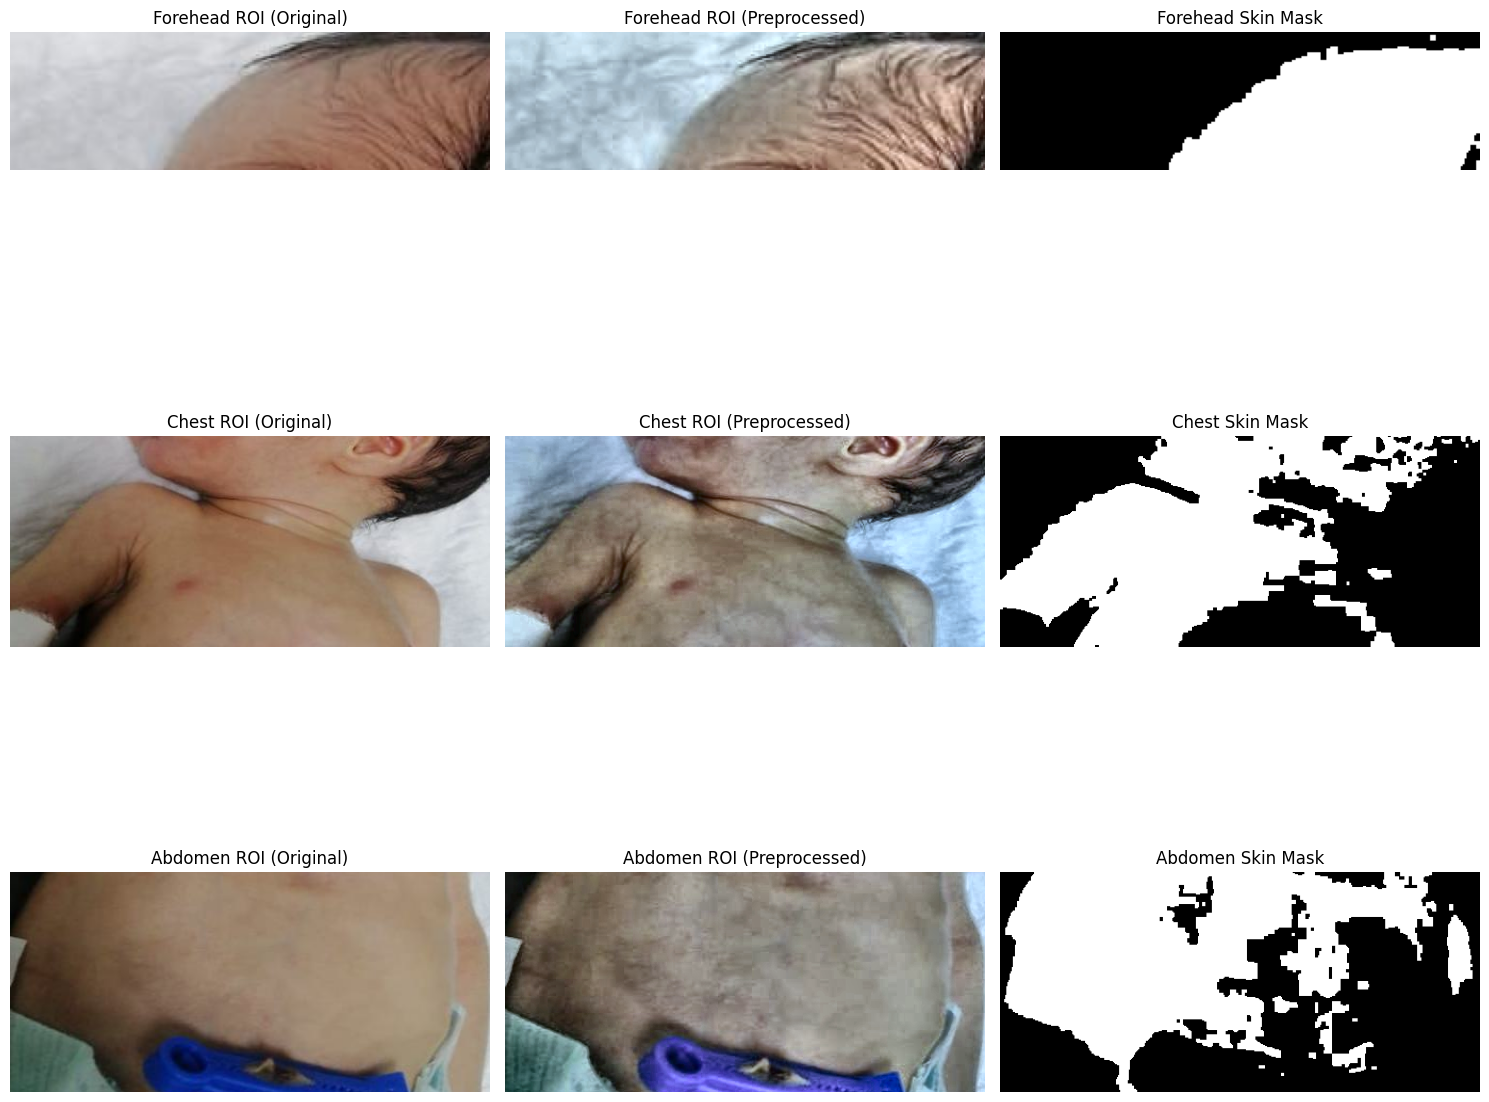

In [30]:
img = cv2.imread(imgs[0])

forehead_roi_original = extract_forehead_roi(img)
chest_roi_original = extract_chest_roi(img)
abdomen_roi_original = extract_abdomen_roi(img)

forehead_roi_preprocessed = preprocess_roi(forehead_roi_original)
chest_roi_preprocessed = preprocess_roi(chest_roi_original)
abdomen_roi_preprocessed = preprocess_roi(abdomen_roi_original)

forehead_mask = skin_mask_hsv(forehead_roi_preprocessed)
chest_mask = skin_mask_hsv(chest_roi_preprocessed)
abdomen_mask = skin_mask_hsv(abdomen_roi_preprocessed)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Forehead
axes[0, 0].imshow(cv2.cvtColor(forehead_roi_original, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Forehead ROI (Original)")
axes[0, 0].axis("off")

axes[0, 1].imshow(cv2.cvtColor(forehead_roi_preprocessed, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Forehead ROI (Preprocessed)")
axes[0, 1].axis("off")

axes[0, 2].imshow(forehead_mask, cmap="gray")
axes[0, 2].set_title("Forehead Skin Mask")
axes[0, 2].axis("off")

# Chest
axes[1, 0].imshow(cv2.cvtColor(chest_roi_original, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Chest ROI (Original)")
axes[1, 0].axis("off")

axes[1, 1].imshow(cv2.cvtColor(chest_roi_preprocessed, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Chest ROI (Preprocessed)")
axes[1, 1].axis("off")

axes[1, 2].imshow(chest_mask, cmap="gray")
axes[1, 2].set_title("Chest Skin Mask")
axes[1, 2].axis("off")

# Abdomen
axes[2, 0].imshow(cv2.cvtColor(abdomen_roi_original, cv2.COLOR_BGR2RGB))
axes[2, 0].set_title("Abdomen ROI (Original)")
axes[2, 0].axis("off")

axes[2, 1].imshow(cv2.cvtColor(abdomen_roi_preprocessed, cv2.COLOR_BGR2RGB))
axes[2, 1].set_title("Abdomen ROI (Preprocessed)")
axes[2, 1].axis("off")

axes[2, 2].imshow(abdomen_mask, cmap="gray")
axes[2, 2].set_title("Abdomen Skin Mask")
axes[2, 2].axis("off")

plt.tight_layout()
plt.show()

Build Aligned Dataset

In [31]:
rows = []
failed = 0

for p, label in tqdm(pairs, desc="Extracting FH/CH/AB features"):
    img = cv2.imread(p)

    if img is None:
        failed += 1
        continue

    fh = extract_forehead_roi(img)
    ch = extract_chest_roi(img)
    ab = extract_abdomen_roi(img)

    if fh is None or ch is None or ab is None:
        failed += 1
        continue

    try:
        fh_feat = extract_features_from_roi(fh)
        ch_feat = extract_features_from_roi(ch)
        ab_feat = extract_features_from_roi(ab)
    except:
        failed += 1
        continue

    row = {"path": p, "label": int(label)}
    row.update({f"FH_{k}": v for k, v in fh_feat.items()})
    row.update({f"CH_{k}": v for k, v in ch_feat.items()})
    row.update({f"AB_{k}": v for k, v in ab_feat.items()})

    rows.append(row)

df_all = pd.DataFrame(rows)

print("df_all shape:", df_all.shape, "Failed:", failed)
print(df_all["label"].value_counts())
df_all.head()

Extracting FH/CH/AB features: 100%|██████████| 760/760 [07:03<00:00,  1.79it/s]


df_all shape: (760, 83) Failed: 0
label
0    560
1    200
Name: count, dtype: int64


,path,label,FH_R_mean,FH_G_mean,FH_B_mean,FH_R_std,FH_G_std,FH_B_std,FH_R_p90,FH_G_p90,...,AB_S_mean,AB_V_mean,AB_V_std,AB_Hue_peak_bin,AB_L_mean,AB_a_mean,AB_Lab_b_mean,AB_Lab_b_p90,AB_yellow_prop,AB_YGI_x_b
0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,160.685455,137.500931,123.755379,31.774710,30.985716,30.639473,200.000000,174.0,...,44.932880,126.077789,26.264019,1.0,125.949501,129.835175,135.406067,140.0,0.191820,310.622720
1,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,132.884811,128.196167,111.781845,17.329346,17.719952,19.079866,155.000000,151.0,...,85.384720,155.243835,47.716450,1.0,139.057159,137.994171,140.739227,153.0,0.236863,355.222065
2,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,145.896698,121.568466,107.705566,45.040203,43.877579,44.392033,200.000000,173.0,...,62.677303,120.599503,49.448494,0.0,110.503212,135.406250,134.982498,139.0,0.204453,319.881296
3,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,130.790695,108.664345,105.437225,54.452568,45.487782,45.459011,206.000000,168.0,...,70.552055,128.813049,42.963402,1.0,120.384712,133.717072,138.266571,145.0,0.192356,341.447896
4,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,124.146736,116.615944,111.375000,40.143158,40.375427,37.647377,176.899994,170.0,...,68.634811,97.587029,30.514870,0.0,92.182625,132.477432,136.132324,141.0,0.197973,336.122572


Split First

In [32]:
train_df, test_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all["label"].astype(int)
)

y_train = train_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train class counts:\n", train_df["label"].value_counts())
print("Test class counts:\n", test_df["label"].value_counts())

Train shape: (608, 83)
Test shape: (152, 83)
Train class counts:
 label
0    448
1    160
Name: count, dtype: int64
Test class counts:
 label
0    112
1     40
Name: count, dtype: int64


Train-only Significant Feature Selection

In [33]:
def select_significant_region_features(train_df, prefix, p_thresh=0.05):
    cols = [c for c in train_df.columns if c.startswith(prefix + "_")]
    results = []

    for col in cols:
        c0 = train_df.loc[train_df["label"] == 0, col].dropna()
        c1 = train_df.loc[train_df["label"] == 1, col].dropna()

        if len(c0) < 10 or len(c1) < 10:
            continue

        t_stat, p_val = ttest_ind(c0, c1, equal_var=False)
        results.append({
            "Feature": col,
            "p_value": float(p_val)
        })

    res_df = pd.DataFrame(results).sort_values("p_value")
    sig_cols = res_df.loc[res_df["p_value"] < p_thresh, "Feature"].tolist()

    if len(sig_cols) == 0:
        sig_cols = cols.copy()

    return res_df, sig_cols


ttest_fh, sig_fh = select_significant_region_features(train_df, "FH")
ttest_ch, sig_ch = select_significant_region_features(train_df, "CH")
ttest_ab, sig_ab = select_significant_region_features(train_df, "AB")

print("Selected FH features:", len(sig_fh))
print("Selected CH features:", len(sig_ch))
print("Selected AB features:", len(sig_ab))

print("\nTop FH features:")
print(ttest_fh.head(10))

print("\nTop CH features:")
print(ttest_ch.head(10))

print("\nTop AB features:")
print(ttest_ab.head(10))

Selected FH features: 2
Selected CH features: 21
Selected AB features: 19

Top FH features:
            Feature   p_value
16        FH_H_mean  0.002053
20  FH_Hue_peak_bin  0.039130
1         FH_G_mean  0.142324
2         FH_B_mean  0.162180
21        FH_L_mean  0.165797
18        FH_V_mean  0.199751
3          FH_R_std  0.200967
0         FH_R_mean  0.250619
22        FH_a_mean  0.257958
4          FH_G_std  0.259837

Top CH features:
          Feature       p_value
2       CH_B_mean  1.878762e-15
24   CH_Lab_b_p90  3.347823e-14
11    CH_G_over_B  4.203368e-14
15        CH_b_ch  1.002881e-13
17      CH_S_mean  1.464375e-12
23  CH_Lab_b_mean  4.751825e-12
9          CH_YGI  6.977289e-12
26     CH_YGI_x_b  7.601149e-12
21      CH_L_mean  7.838561e-10
1       CH_G_mean  9.530549e-10

Top AB features:
         Feature   p_value
11   AB_G_over_B  0.000015
2      AB_B_mean  0.000018
16     AB_H_mean  0.000039
0      AB_R_mean  0.000066
18     AB_V_mean  0.000068
15       AB_b_ch  0.000159
2

Build Region Matrices

In [34]:
Xfh_train = train_df[sig_fh]
Xch_train = train_df[sig_ch]
Xab_train = train_df[sig_ab]

Xfh_test = test_df[sig_fh]
Xch_test = test_df[sig_ch]
Xab_test = test_df[sig_ab]

Base Model Pipeline

In [35]:
def make_base_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

OOF Base Probabilities on Training Only

In [36]:
base_fh = make_base_model()
base_ch = make_base_model()
base_ab = make_base_model()

prob_fh_oof = cross_val_predict(base_fh, Xfh_train, y_train, cv=cv, method="predict_proba")[:, 1]
prob_ch_oof = cross_val_predict(base_ch, Xch_train, y_train, cv=cv, method="predict_proba")[:, 1]
prob_ab_oof = cross_val_predict(base_ab, Xab_train, y_train, cv=cv, method="predict_proba")[:, 1]

stack_train = np.vstack([prob_fh_oof, prob_ch_oof, prob_ab_oof]).T
print("Stack train meta-feature shape:", stack_train.shape)

Stack train meta-feature shape: (608, 3)


Meta Learner OOF AUC on Train

In [37]:
meta = LogisticRegression(max_iter=2000)

prob_meta_oof = cross_val_predict(meta, stack_train, y_train, cv=cv, method="predict_proba")[:, 1]
stack_oof_auc = roc_auc_score(y_train, prob_meta_oof)

print("Stacking OOF AUC:", stack_oof_auc)

Stacking OOF AUC: 0.7251813616071427


Fit Base Models on Full Train, Build Test Meta Features

In [38]:
base_fh.fit(Xfh_train, y_train)
base_ch.fit(Xch_train, y_train)
base_ab.fit(Xab_train, y_train)

prob_fh_test = base_fh.predict_proba(Xfh_test)[:, 1]
prob_ch_test = base_ch.predict_proba(Xch_test)[:, 1]
prob_ab_test = base_ab.predict_proba(Xab_test)[:, 1]

stack_test = np.vstack([prob_fh_test, prob_ch_test, prob_ab_test]).T
print("Stack test meta-feature shape:", stack_test.shape)

Stack test meta-feature shape: (152, 3)


Fit Meta Learner + Default Threshold Evaluation

In [39]:
meta.fit(stack_train, y_train)

prob = meta.predict_proba(stack_test)[:, 1]
pred = (prob >= 0.5).astype(int)

print("=== Stacking Test Report (thr=0.5) ===")
print(classification_report(y_test, pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

=== Stacking Test Report (thr=0.5) ===
              precision    recall  f1-score   support

           0     0.7432    0.9821    0.8462       112
           1     0.5000    0.0500    0.0909        40

    accuracy                         0.7368       152
   macro avg     0.6216    0.5161    0.4685       152
weighted avg     0.6792    0.7368    0.6474       152

Confusion Matrix:
 [[110   2]
 [ 38   2]]


ROC, AUC, PR Curve, AP

Stacking Test AUC: 0.728125
Stacking PR AP: 0.4384895004693322


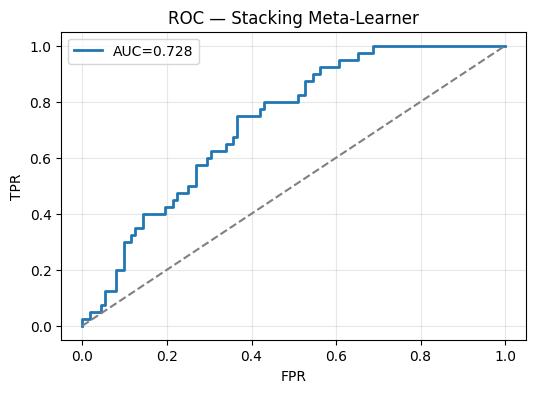

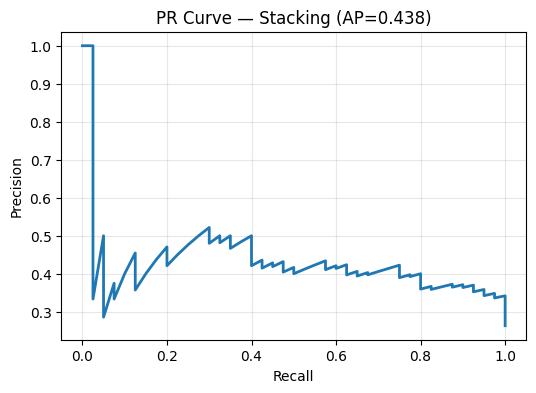

In [42]:
fpr, tpr, thr = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)
ap = average_precision_score(y_test, prob)

print("Stacking Test AUC:", roc_auc)
print("Stacking PR AP:", ap)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC — Stacking Meta-Learner")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

prec_curve, rec_curve, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(6, 4))
plt.plot(rec_curve, prec_curve, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve — Stacking (AP={ap:.3f})")
plt.grid(alpha=0.3)
plt.show()

Youden Threshold Evaluation

In [43]:
j = tpr - fpr
best_idx = np.argmax(j)
best_thr = thr[best_idx]

print("Best Threshold (Youden J):", best_thr)
print("At Youden -> FPR:", fpr[best_idx], "TPR(Recall):", tpr[best_idx])

pred_y = (prob >= best_thr).astype(int)

print("\n=== Report @ Youden Threshold (Stacking V2) ===")
print(classification_report(y_test, pred_y, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_y))

Best Threshold (Youden J): 0.2374590927723724
At Youden -> FPR: 0.36607142857142855 TPR(Recall): 0.75

=== Report @ Youden Threshold (Stacking V2) ===
              precision    recall  f1-score   support

           0     0.8765    0.6339    0.7358       112
           1     0.4225    0.7500    0.5405        40

    accuracy                         0.6645       152
   macro avg     0.6495    0.6920    0.6381       152
weighted avg     0.7571    0.6645    0.6844       152

Confusion Matrix:
 [[71 41]
 [10 30]]


Brier Score + Calibration Curve

Stacking Brier Score: 0.17462745965673368


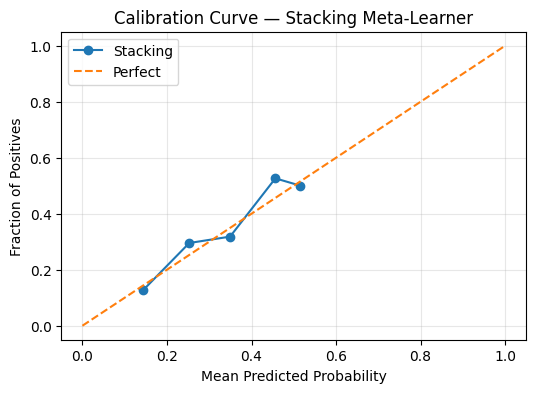

In [45]:
brier = brier_score_loss(y_test, prob)
print("Stacking Brier Score:", brier)

frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)

plt.figure(figsize=(6, 4))
plt.plot(mean_pred, frac_pos, "o-", label="Stacking")
plt.plot([0, 1], [0, 1], "--", label="Perfect")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Stacking Meta-Learner")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Meta Weights

In [46]:
print("Meta weights [FH, CH, AB]:", meta.coef_[0])

Meta weights [FH, CH, AB]: [0.22607215 2.78206914 2.58178006]


95% CI for AUC

In [47]:
def auc_bootstrap_ci(y_true, y_prob, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_b = y_true[idx]
        p_b = y_prob[idx]

        if len(np.unique(y_b)) < 2:
            continue

        aucs.append(roc_auc_score(y_b, p_b))

    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

auc_ci_low, auc_ci_high = auc_bootstrap_ci(y_test, prob)
print(f"95% CI for AUC: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")

95% CI for AUC: [0.6399, 0.8095]


95% CI for Brier

In [48]:
boot_brier = []

for i in range(2000):
    y_res, p_res = resample(
        np.array(y_test),
        np.array(prob),
        stratify=np.array(y_test),
        random_state=i
    )
    boot_brier.append(brier_score_loss(y_res, p_res))

brier_ci_low = np.percentile(boot_brier, 2.5)
brier_ci_high = np.percentile(boot_brier, 97.5)

print(f"95% CI for Brier Score: [{brier_ci_low:.4f}, {brier_ci_high:.4f}]")

95% CI for Brier Score: [0.1592, 0.1902]


Final Table 1 + Table 2

In [49]:
# final Youden metrics
tn, fp, fn, tp = confusion_matrix(y_test, pred_y).ravel()
acc  = accuracy_score(y_test, pred_y)
prec = precision_score(y_test, pred_y, zero_division=0)
rec  = recall_score(y_test, pred_y, zero_division=0)
spec = tn / (tn + fp)
f1   = f1_score(y_test, pred_y, zero_division=0)
cm   = [[int(tn), int(fp)], [int(fn), int(tp)]]

print("\nStacking (meta-learner) — Table 1")
print(f"OOF AUC: {stack_oof_auc:.4f}")
print(f"Test AUC: {roc_auc:.4f}")
print(f"95% CI (AUC): [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")
print(f"PR AP: {ap:.4f}")
print(f"Brier score: {brier:.4f}")
print(f"95% CI (Brier): [{brier_ci_low:.4f}, {brier_ci_high:.4f}]")

print("\nStacking (meta-learner) — Table 2 (Youden J)")
print("Threshold rule: Youden J")
print(f"Threshold: {best_thr:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"Specificity: {spec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Confusion matrix: {cm}")


Stacking (meta-learner) — Table 1
OOF AUC: 0.7252
Test AUC: 0.7281
95% CI (AUC): [0.6399, 0.8095]
PR AP: 0.4385
Brier score: 0.1746
95% CI (Brier): [0.1592, 0.1902]

Stacking (meta-learner) — Table 2 (Youden J)
Threshold rule: Youden J
Threshold: 0.2375
Accuracy: 0.6645
Precision: 0.4225
Recall: 0.7500
Specificity: 0.6339
F1-score: 0.5405
Confusion matrix: [[71, 41], [10, 30]]


Optional Default-threshold Summary

In [50]:
tn0, fp0, fn0, tp0 = confusion_matrix(y_test, pred).ravel()

acc0  = accuracy_score(y_test, pred)
prec0 = precision_score(y_test, pred, zero_division=0)
rec0  = recall_score(y_test, pred, zero_division=0)
spec0 = tn0 / (tn0 + fp0)
f10   = f1_score(y_test, pred, zero_division=0)
cm0   = [[int(tn0), int(fp0)], [int(fn0), int(tp0)]]

print("\nStacking (meta-learner) — Default Threshold 0.50")
print("Threshold rule: Fixed")
print("Threshold: 0.5000")
print(f"Accuracy: {acc0:.4f}")
print(f"Precision: {prec0:.4f}")
print(f"Recall: {rec0:.4f}")
print(f"Specificity: {spec0:.4f}")
print(f"F1-score: {f10:.4f}")
print(f"Confusion matrix: {cm0}")


Stacking (meta-learner) — Default Threshold 0.50
Threshold rule: Fixed
Threshold: 0.5000
Accuracy: 0.7368
Precision: 0.5000
Recall: 0.0500
Specificity: 0.9821
F1-score: 0.0909
Confusion matrix: [[110, 2], [38, 2]]


In [ ]:
summary_table1 = pd.DataFrame([{
    "Approach": "Stacking (meta-learner)",
    "OOF AUC": round(stack_oof_auc, 4),
    "Test AUC": round(roc_auc, 4),
    "95% CI (AUC)": f"[{auc_ci_low:.4f}, {auc_ci_high:.4f}]",
    "PR AP": round(ap, 4),
    "Brier Score": round(brier, 4),
    "95% CI (Brier)": f"[{brier_ci_low:.4f}, {brier_ci_high:.4f}]"
}])

summary_table2 = pd.DataFrame([{
    "Approach": "Stacking (meta-learner)",
    "Threshold rule": "Youden J",
    "Threshold": round(best_thr, 4),
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "Specificity": round(spec, 4),
    "F1-score": round(f1, 4),
    "Confusion matrix": str(cm)
}])

summary_table1.to_csv("stacking_v2_table1.csv", index=False)
summary_table2.to_csv("stacking_v2_table2.csv", index=False)

print("Saved: stacking_v2_table1.csv")
print("Saved: stacking_v2_table2.csv")

summary_table1, summary_table2

In [ ]:
meta_train_df = pd.DataFrame(stack_train, columns=["FH_prob_oof", "CH_prob_oof", "AB_prob_oof"])
meta_train_df["label"] = y_train
meta_train_df.to_csv("stacking_v2_meta_train.csv", index=False)

meta_test_df = pd.DataFrame(stack_test, columns=["FH_prob_test", "CH_prob_test", "AB_prob_test"])
meta_test_df["label"] = y_test
meta_test_df["stack_prob"] = prob
meta_test_df.to_csv("stacking_v2_meta_test.csv", index=False)

print("Saved: stacking_v2_meta_train.csv")
print("Saved: stacking_v2_meta_test.csv")